## Installation and importing data from source

In [1]:
pip install ucimlrepo


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import certifi

# Ensure Python's SSL module can find valid CA certs; without this, ucimlrepo's
# internal pandas.read_csv call fails SSL verification and gets misreported as
# DatasetNotFoundError instead of the real certificate error.
os.environ.setdefault('SSL_CERT_FILE', certifi.where())

from ucimlrepo import fetch_ucirepo

# fetch dataset
phishing_websites = fetch_ucirepo(id=327)

# data (as pandas dataframes)
X = phishing_websites.data.features
y = phishing_websites.data.targets

# metadata
print(phishing_websites.metadata)

# variable information
print(phishing_websites.variables)


{'uci_id': 327, 'name': 'Phishing Websites', 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites', 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv', 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 11055, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Tue Mar 05 2024', 'dataset_doi': '10.24432/C51W2X', 'creators': ['Rami Mohammad', 'Lee McCluskey'], 'intro_paper': {'ID': 396, 'type': 'NATIVE', 'title': 'An assessment of features related to phishing websites using an automated technique', 'authors': 'R. Mohammad, F. Thabtah, L. Mccluskey', 'venue': 'International Conference for Internet Tec

## Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loaded set

In [4]:
X.head()

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,1,-1,-1,-1,-1,1,1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,-1,-1,0,-1,1,1,1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,1,-1,1,-1,1,0,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,1,-1,1,-1,1
4,1,0,-1,1,1,-1,1,1,-1,1,...,1,-1,1,-1,-1,0,-1,1,1,1


In [5]:
y.head()

,result
0,-1
1,-1
2,-1
3,-1
4,1


## Dataset overview

In [6]:
X.describe().round(2)

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
count,11055.00,11055.00,11055.00,11055.00,11055.00,11055.00,11055.00,11055.00,11055.00,11055.00,...,11055.00,11055.00,11055.00,11055.00,11055.00,11055.00,11055.00,11055.00,11055.00,11055.00
mean,0.31,-0.63,0.74,0.70,0.74,-0.73,0.06,0.25,-0.34,0.63,...,0.91,0.61,0.82,0.06,0.38,0.29,-0.48,0.72,0.34,0.72
std,0.95,0.77,0.67,0.71,0.67,0.68,0.82,0.91,0.94,0.78,...,0.41,0.79,0.58,1.00,0.93,0.83,0.88,0.69,0.57,0.69
min,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,...,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00,-1.00
25%,-1.00,-1.00,1.00,1.00,1.00,-1.00,-1.00,-1.00,-1.00,1.00,...,1.00,1.00,1.00,-1.00,-1.00,0.00,-1.00,1.00,0.00,1.00
50%,1.00,-1.00,1.00,1.00,1.00,-1.00,0.00,1.00,-1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,-1.00,1.00,0.00,1.00
75%,1.00,-1.00,1.00,1.00,1.00,-1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [7]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   having_ip_address           11055 non-null  int64
 1   url_length                  11055 non-null  int64
 2   shortining_service          11055 non-null  int64
 3   having_at_symbol            11055 non-null  int64
 4   double_slash_redirecting    11055 non-null  int64
 5   prefix_suffix               11055 non-null  int64
 6   having_sub_domain           11055 non-null  int64
 7   sslfinal_state              11055 non-null  int64
 8   domain_registration_length  11055 non-null  int64
 9   favicon                     11055 non-null  int64
 10  port                        11055 non-null  int64
 11  https_token                 11055 non-null  int64
 12  request_url                 11055 non-null  int64
 13  url_of_anchor               11055 non-null  int64
 14  links_in_tags    

In [8]:
X.isna().sum()

having_ip_address             0
url_length                    0
shortining_service            0
having_at_symbol              0
double_slash_redirecting      0
prefix_suffix                 0
having_sub_domain             0
sslfinal_state                0
domain_registration_length    0
favicon                       0
port                          0
https_token                   0
request_url                   0
url_of_anchor                 0
links_in_tags                 0
sfh                           0
submitting_to_email           0
abnormal_url                  0
redirect                      0
on_mouseover                  0
rightclick                    0
popupwindow                   0
iframe                        0
age_of_domain                 0
dnsrecord                     0
web_traffic                   0
page_rank                     0
google_index                  0
links_pointing_to_page        0
statistical_report            0
dtype: int64

Dataset is said to have no missing values, which after double checking is true. All features are int64, and inbetween range (-1,1).

In [9]:
X.duplicated().sum()

np.int64(5270)

`X.duplicated().sum()` returns `np.int64(5270)`, meaning 5,270 rows in X are exact duplicates of a previous row (same values across all feature columns). That's out of 11,055 total rows, so roughly 48% of the rows in X are duplicates.


In [10]:
pd.concat([X, y], axis=1).duplicated().sum()

np.int64(5206)

That gap (5270 vs 5206 = 64) is the important part — it's label noise, not just redundancy.

  - 5,206 rows are true full duplicates: identical features and identical target as an earlier row.
  - 5,270 rows are duplicates on features alone.
  - The difference, 64, is the number of distinct feature-vectors that appear more than once with conflicting labels — same 30 features, but classified as phishing in some
    rows and legitimate in others.
  - Those 64 conflicting feature-vectors touch 357 rows total in the dataset

**Note:** 357 rows share identical features with at least one other row but have a different label. These are conflicting/noisy examples that no purely feature-based model can classify correctly for both copies.

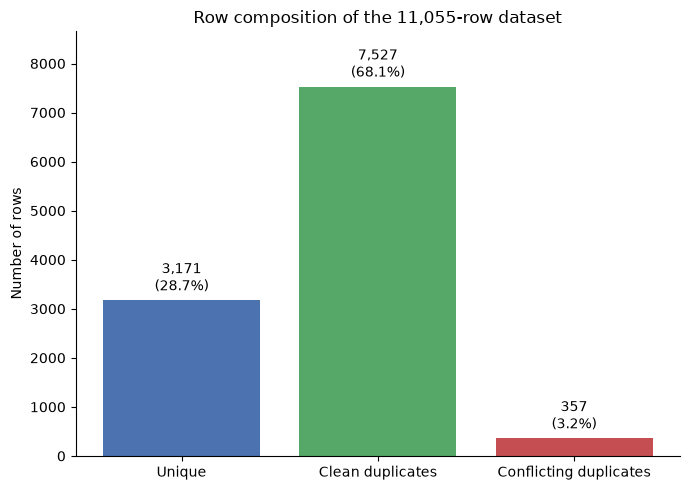

In [11]:
data = pd.concat([X, y], axis=1)
feature_cols = X.columns.tolist()
target_col = y.columns[0]

group_size = data.groupby(feature_cols)[target_col].transform('size')
group_label_nunique = data.groupby(feature_cols)[target_col].transform('nunique')

is_conflicting = group_label_nunique > 1
is_clean_duplicate = ~is_conflicting & (group_size > 1)
is_unique = group_size == 1

row_status = pd.Series(
    np.select(
        [is_conflicting, is_clean_duplicate, is_unique],
        ['Conflicting duplicates', 'Clean duplicates', 'Unique'],
        default='Unique',
    ),
    index=data.index,
)

status_order = ['Unique', 'Clean duplicates', 'Conflicting duplicates']
status_counts = row_status.value_counts().reindex(status_order)
status_pct = status_counts / len(data) * 100

colors = ['#4C72B0', '#55A868', '#C44E52']
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(status_counts.index, status_counts.values, color=colors)

for bar, count, pct in zip(bars, status_counts.values, status_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + len(data) * 0.01,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10,
    )

ax.set_ylabel('Number of rows')
ax.set_title(f'Row composition of the {len(data):,}-row dataset')
ax.set_ylim(0, status_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()


## Per-feature distributions

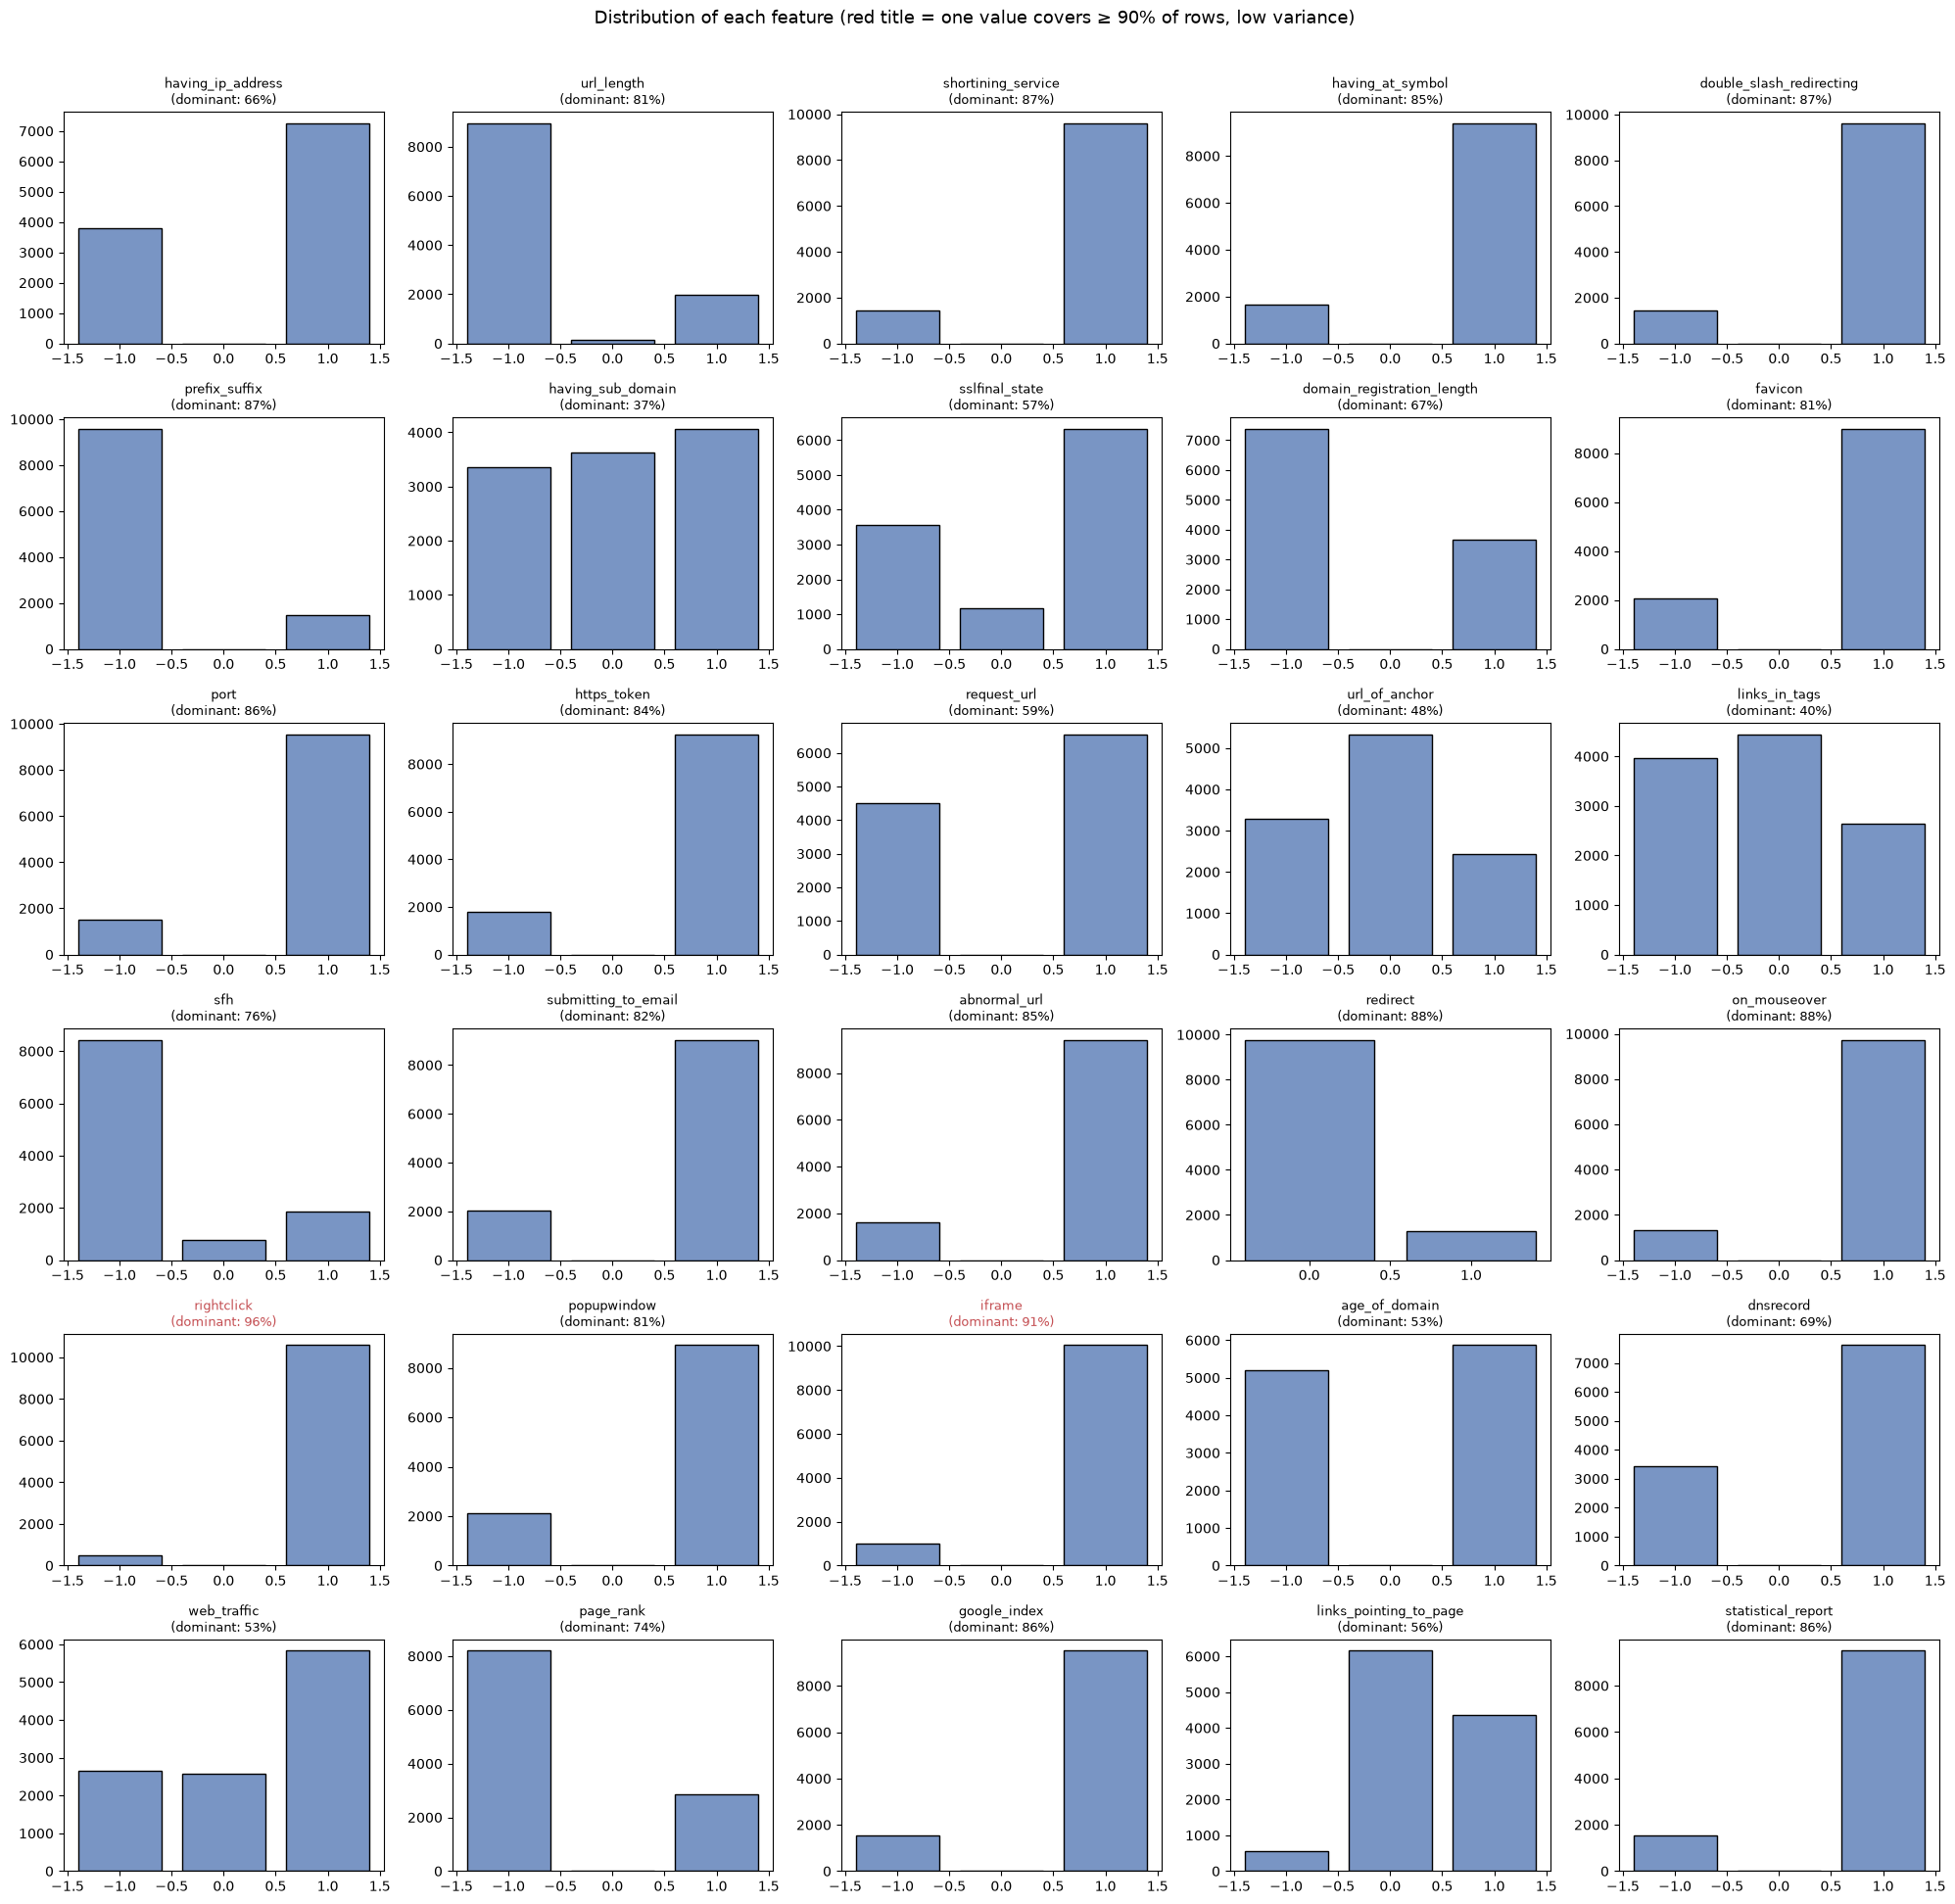

In [12]:
n_cols = 5
n_rows = int(np.ceil(len(X.columns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.2))
axes = axes.flatten()

for ax, col in zip(axes, X.columns):
    sns.histplot(data=X, x=col, discrete=True, shrink=0.8, ax=ax, color='#4C72B0')
    dominant_pct = X[col].value_counts(normalize=True).max() * 100
    title_color = '#C44E52' if dominant_pct >= 90 else 'black'
    ax.set_title(f'{col}\n(dominant: {dominant_pct:.0f}%)', fontsize=9, color=title_color)
    ax.set_xlabel('')
    ax.set_ylabel('')

for ax in axes[len(X.columns):]:
    ax.axis('off')

fig.suptitle(
    'Distribution of each feature (red title = one value covers ≥ 90% of rows, low variance)',
    y=1.01, fontsize=13,
)
plt.tight_layout()
plt.show()


## Feature correlation

Histogram shape alone can be misleading (two features can look alike but differ row-by-row). This checks pairwise correlation directly to find genuinely redundant features.

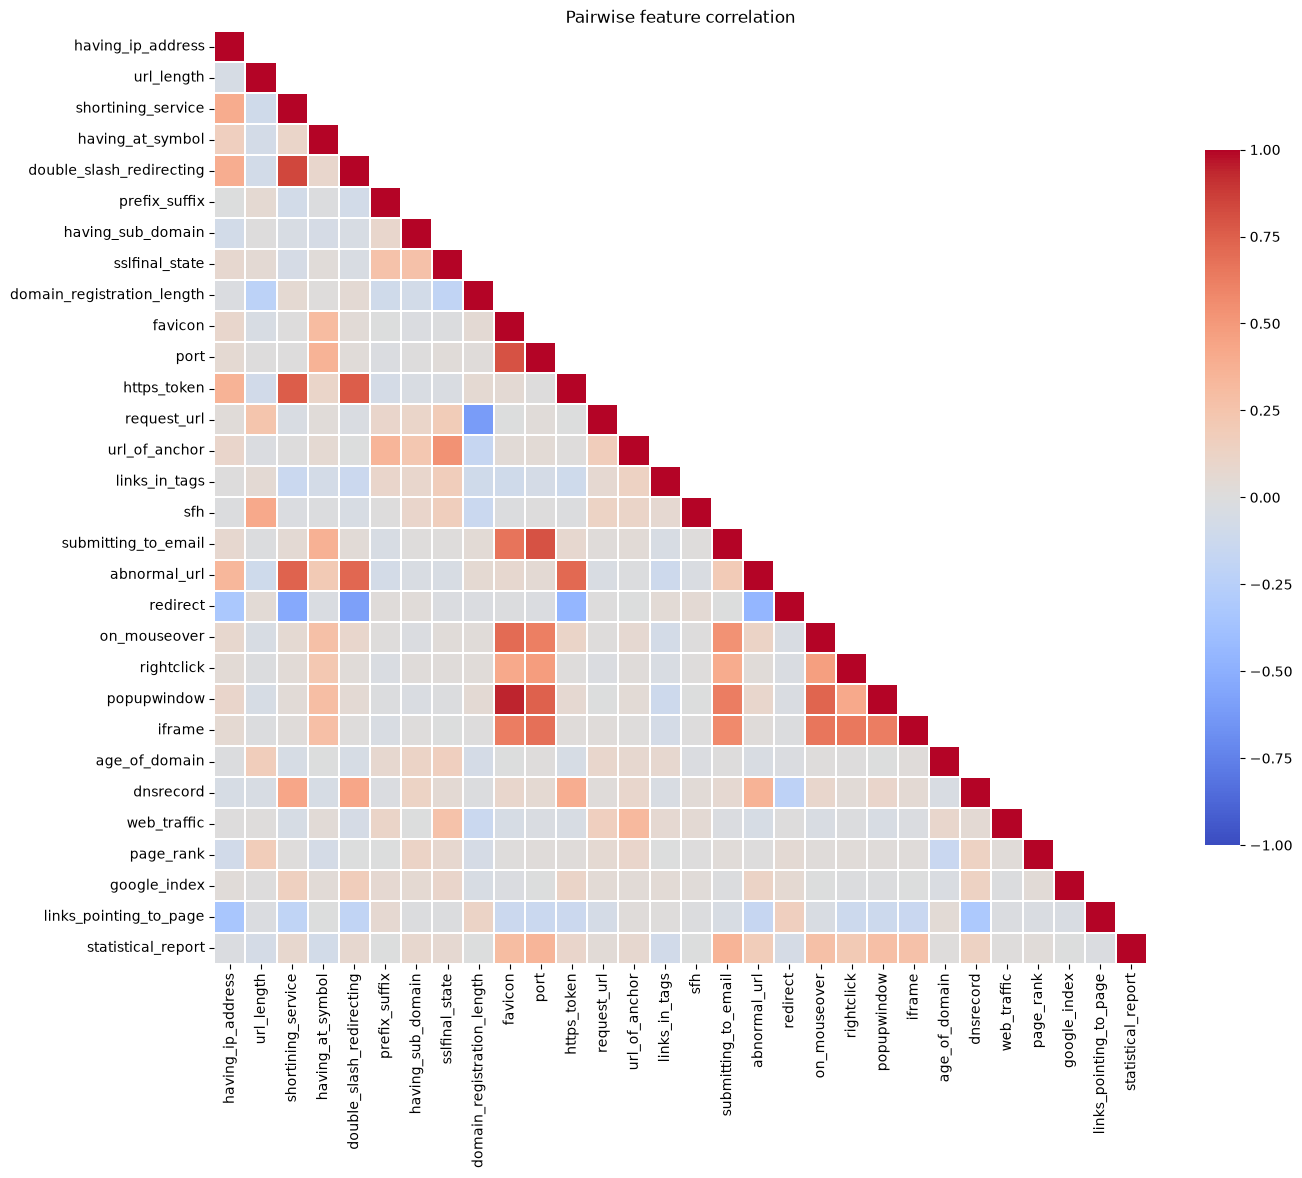

In [13]:
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.3, cbar_kws={'shrink': 0.7},
)
plt.title('Pairwise feature correlation')
plt.tight_layout()
plt.show()


In [14]:
top_pairs = (
    corr.where(mask)
    .stack()
    .rename('correlation')
    .sort_values(key=abs, ascending=False)
)
top_pairs.head(15).to_frame()


,,correlation
favicon,popupwindow,0.939633
shortining_service,double_slash_redirecting,0.842796
favicon,port,0.803834
port,submitting_to_email,0.799088
double_slash_redirecting,https_token,0.760799
shortining_service,https_token,0.757838
port,popupwindow,0.748517
shortining_service,abnormal_url,0.739290
on_mouseover,popupwindow,0.733629
double_slash_redirecting,abnormal_url,0.723724


## Dropping redundant features

`favicon` and `popupwindow` are the most correlated pair in the dataset (r = 0.94). Dropping both, keeping every other feature as-is.

In [15]:
X = X.drop(columns=['favicon', 'popupwindow'])
print(f'Remaining features: {X.shape[1]}')
X.head()


Remaining features: 28


,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,port,...,on_mouseover,rightclick,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,1,-1,-1,-1,-1,1,1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,-1,-1,0,-1,1,1,1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,1,-1,1,-1,1,0,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,1,-1,1,-1,1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,1,-1,-1,0,-1,1,1,1


## Data set insights and next steps

The dataset is clean: no missing values, every feature is an integer already scaled into a `{-1, 0, 1}` (or `{-1, 1}`) range, and nothing needs imputing or type conversion. Practically, that means no scaling and no encoding step is required before fitting — it's ready to go straight into a model, as you said.

One nuance worth naming even though it doesn't change the plan: these columns are technically categorical/ordinal (each `-1`/`0`/`1` is a discrete signal like "suspicious" / "unsure" / "safe"), not continuous measurements. The reason it's fine to feed them into Logistic Regression as-is is that the encoding already imposes a sensible order (`-1` = bad signal → `1` = good signal), so treating them as numeric doesn't distort anything the way it would for an unordered category (e.g. a country code). If a tree-based model is tried later, this distinction stops mattering entirely, since trees split on thresholds regardless of whether the values are ordinal or continuous.

Two things I'd flag before treating current results as final:

1. **Train/test leakage risk from duplicates.** Earlier in this notebook, 68% of rows turned out to be duplicates of another row (7,527 clean duplicates + 357 conflicting ones). A plain random `train_test_split` doesn't know that — it can easily put a row and its exact duplicate on opposite sides of the split, which lets the model "memorize" test rows it effectively already saw in training. That likely inflates the 0.93 accuracy / 0.98 AUC seen above. Worth redoing the split after deduplicating `X`/`y` (or at least checking how much train/test overlap exists) to get an honest number.
2. **357 conflicting rows put a ceiling on achievable accuracy.** Since ~3.2% of rows have identical features but opposite labels, no feature-based model can ever classify both copies correctly — meaning ~96.8% is roughly the practical accuracy ceiling on this feature set, not 100%. Current results are already close to that, so squeezing out more headroom probably means fixing the label noise, not tuning the model further.

My suggestions from here, roughly in order of value for the effort:
- **Deduplicate before splitting** (point 1 above) and re-run the baseline to see how much the metrics move — this affects whether the 0.93/0.98 numbers can be trusted at all.
- **Try a tree ensemble** (`RandomForestClassifier` or `GradientBoostingClassifier`) alongside Logistic Regression — this exact dataset is known in the literature to respond well to trees because a few features (`sslfinal_state`, `url_of_anchor`, `web_traffic`) interact non-linearly with each other, which a linear model can't capture.
- **Cross-validation instead of a single split** for a more stable estimate, given how sensitive a single split is to the duplicate-leakage issue above.
- **Feature importance from a tree model**, compared against the correlation clusters already found (`favicon`/`port`/`popupwindow`/`on_mouseover`/`rightclick`/`iframe`) — a good sanity check on whether trimming that cluster further is worth it.


## Baseline model: Logistic Regression

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
)

y_flat = y.values.ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_flat, test_size=0.2, stratify=y_flat, random_state=42,
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


In [17]:
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred))
print('Confusion matrix (rows=actual, cols=predicted, labels=[-1, 1]):')
print(confusion_matrix(y_test, y_pred, labels=[-1, 1]))

auc = roc_auc_score(y_test, y_proba)
print(f'\nROC AUC: {auc:.4f}')


Accuracy: 0.9290

              precision    recall  f1-score   support

          -1       0.93      0.90      0.92       980
           1       0.92      0.95      0.94      1231

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211

Confusion matrix (rows=actual, cols=predicted, labels=[-1, 1]):
[[ 885   95]
 [  62 1169]]

ROC AUC: 0.9805


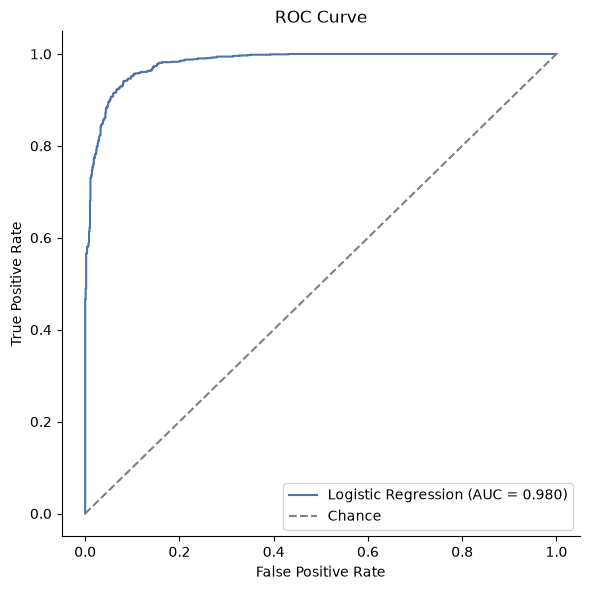

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label=1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='#4C72B0', label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()


## Balanced class weights

In [19]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_bal = model_balanced.predict(X_test)
y_proba_bal = model_balanced.predict_proba(X_test)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred_bal):.4f}')
print()
print(classification_report(y_test, y_pred_bal))
print('Confusion matrix (rows=actual, cols=predicted, labels=[-1, 1]):')
print(confusion_matrix(y_test, y_pred_bal, labels=[-1, 1]))

auc_bal = roc_auc_score(y_test, y_proba_bal)
print(f'\nROC AUC: {auc_bal:.4f}')


Accuracy: 0.9308

              precision    recall  f1-score   support

          -1       0.92      0.92      0.92       980
           1       0.94      0.94      0.94      1231

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211

Confusion matrix (rows=actual, cols=predicted, labels=[-1, 1]):
[[ 901   79]
 [  74 1157]]

ROC AUC: 0.9806


In [20]:
from sklearn.metrics import recall_score

comparison = pd.DataFrame({
    'default': {
        'recall (-1, phishing)': recall_score(y_test, y_pred, pos_label=-1),
        'recall (1, legitimate)': recall_score(y_test, y_pred, pos_label=1),
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': auc,
    },
    'balanced': {
        'recall (-1, phishing)': recall_score(y_test, y_pred_bal, pos_label=-1),
        'recall (1, legitimate)': recall_score(y_test, y_pred_bal, pos_label=1),
        'accuracy': accuracy_score(y_test, y_pred_bal),
        'roc_auc': auc_bal,
    },
}).T
comparison.round(4)


,"recall (-1, phishing)","recall (1, legitimate)",accuracy,roc_auc
default,0.9031,0.9496,0.9290,0.9805
balanced,0.9194,0.9399,0.9308,0.9806


## Re-checking the baseline after deduplication

Dropping exact duplicate rows (same features *and* same label) before splitting, so identical rows can't end up on both sides of the train/test split. The 357 conflicting rows (same features, different labels) are left in — they're a label-noise issue, not a duplication/leakage issue.

In [21]:
full = pd.concat([X, y], axis=1)
full_dedup = full.drop_duplicates().reset_index(drop=True)

X_dedup = full_dedup[X.columns]
y_dedup = full_dedup[target_col].values

print(f'Rows before dedup: {len(full):,}')
print(f'Rows after dedup:  {len(full_dedup):,}')


Rows before dedup: 11,055
Rows after dedup:  5,817


In [22]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dedup, y_dedup, test_size=0.2, stratify=y_dedup, random_state=42,
)

model_dedup = LogisticRegression(max_iter=1000)
model_dedup.fit(X_train_d, y_train_d)

y_pred_dedup = model_dedup.predict(X_test_d)
y_proba_dedup = model_dedup.predict_proba(X_test_d)[:, 1]

print(f'Accuracy: {accuracy_score(y_test_d, y_pred_dedup):.4f}')
print()
print(classification_report(y_test_d, y_pred_dedup))
print('Confusion matrix (rows=actual, cols=predicted, labels=[-1, 1]):')
print(confusion_matrix(y_test_d, y_pred_dedup, labels=[-1, 1]))

auc_dedup = roc_auc_score(y_test_d, y_proba_dedup)
print(f'\nROC AUC: {auc_dedup:.4f}')


Accuracy: 0.9167

              precision    recall  f1-score   support

          -1       0.93      0.91      0.92       603
           1       0.90      0.93      0.91       561

    accuracy                           0.92      1164
   macro avg       0.92      0.92      0.92      1164
weighted avg       0.92      0.92      0.92      1164

Confusion matrix (rows=actual, cols=predicted, labels=[-1, 1]):
[[546  57]
 [ 40 521]]

ROC AUC: 0.9707


In [23]:
leak_comparison = pd.DataFrame({
    'original (leaky) split': {
        'recall (-1, phishing)': recall_score(y_test, y_pred, pos_label=-1),
        'recall (1, legitimate)': recall_score(y_test, y_pred, pos_label=1),
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': auc,
    },
    'deduplicated split': {
        'recall (-1, phishing)': recall_score(y_test_d, y_pred_dedup, pos_label=-1),
        'recall (1, legitimate)': recall_score(y_test_d, y_pred_dedup, pos_label=1),
        'accuracy': accuracy_score(y_test_d, y_pred_dedup),
        'roc_auc': auc_dedup,
    },
}).T
leak_comparison.round(4)


,"recall (-1, phishing)","recall (1, legitimate)",accuracy,roc_auc
original (leaky) split,0.9031,0.9496,0.9290,0.9805
deduplicated split,0.9055,0.9287,0.9167,0.9707


## Tree-based models

Comparing Logistic Regression against Random Forest and Gradient Boosting on the same deduplicated split, since trees can capture non-linear feature interactions a linear model can't.

In [24]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train_d, y_train_d)
y_pred_rf = rf_model.predict(X_test_d)
y_proba_rf = rf_model.predict_proba(X_test_d)[:, 1]

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_d, y_train_d)
y_pred_gb = gb_model.predict(X_test_d)
y_proba_gb = gb_model.predict_proba(X_test_d)[:, 1]

for name, y_pred_i, y_proba_i in [
    ('Random Forest', y_pred_rf, y_proba_rf),
    ('Gradient Boosting', y_pred_gb, y_proba_gb),
]:
    print(f'=== {name} ===')
    print(f'Accuracy: {accuracy_score(y_test_d, y_pred_i):.4f}')
    print(classification_report(y_test_d, y_pred_i))
    print(f'ROC AUC: {roc_auc_score(y_test_d, y_proba_i):.4f}')
    print()


=== Random Forest ===
Accuracy: 0.9476
              precision    recall  f1-score   support

          -1       0.96      0.94      0.95       603
           1       0.93      0.96      0.95       561

    accuracy                           0.95      1164
   macro avg       0.95      0.95      0.95      1164
weighted avg       0.95      0.95      0.95      1164

ROC AUC: 0.9881

=== Gradient Boosting ===
Accuracy: 0.9424
              precision    recall  f1-score   support

          -1       0.96      0.93      0.94       603
           1       0.93      0.96      0.94       561

    accuracy                           0.94      1164
   macro avg       0.94      0.94      0.94      1164
weighted avg       0.94      0.94      0.94      1164

ROC AUC: 0.9866



In [25]:
model_comparison = pd.DataFrame({
    'Logistic Regression': {
        'recall (-1, phishing)': recall_score(y_test_d, y_pred_dedup, pos_label=-1),
        'recall (1, legitimate)': recall_score(y_test_d, y_pred_dedup, pos_label=1),
        'accuracy': accuracy_score(y_test_d, y_pred_dedup),
        'roc_auc': auc_dedup,
    },
    'Random Forest': {
        'recall (-1, phishing)': recall_score(y_test_d, y_pred_rf, pos_label=-1),
        'recall (1, legitimate)': recall_score(y_test_d, y_pred_rf, pos_label=1),
        'accuracy': accuracy_score(y_test_d, y_pred_rf),
        'roc_auc': roc_auc_score(y_test_d, y_proba_rf),
    },
    'Gradient Boosting': {
        'recall (-1, phishing)': recall_score(y_test_d, y_pred_gb, pos_label=-1),
        'recall (1, legitimate)': recall_score(y_test_d, y_pred_gb, pos_label=1),
        'accuracy': accuracy_score(y_test_d, y_pred_gb),
        'roc_auc': roc_auc_score(y_test_d, y_proba_gb),
    },
}).T
model_comparison.round(4)


,"recall (-1, phishing)","recall (1, legitimate)",accuracy,roc_auc
Logistic Regression,0.9055,0.9287,0.9167,0.9707
Random Forest,0.9370,0.9590,0.9476,0.9881
Gradient Boosting,0.9287,0.9572,0.9424,0.9866


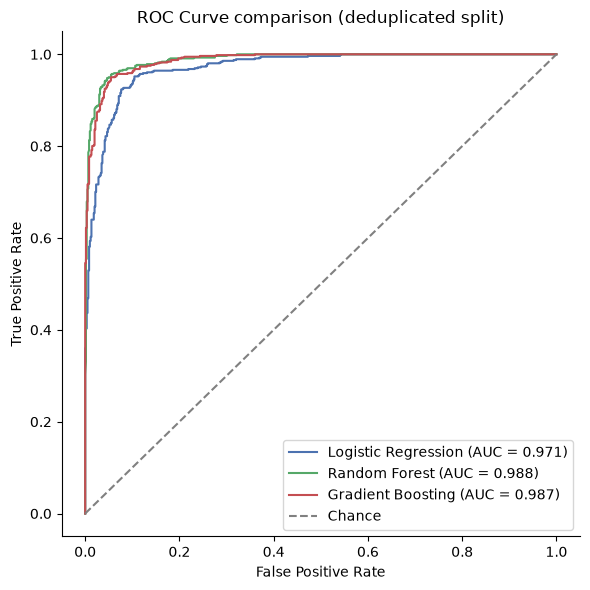

In [26]:
fpr_lr, tpr_lr, _ = roc_curve(y_test_d, y_proba_dedup, pos_label=1)
fpr_rf, tpr_rf, _ = roc_curve(y_test_d, y_proba_rf, pos_label=1)
fpr_gb, tpr_gb, _ = roc_curve(y_test_d, y_proba_gb, pos_label=1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_dedup:.3f})', color='#4C72B0')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test_d, y_proba_rf):.3f})', color='#55A868')
ax.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_score(y_test_d, y_proba_gb):.3f})', color='#C44E52')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve comparison (deduplicated split)')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()


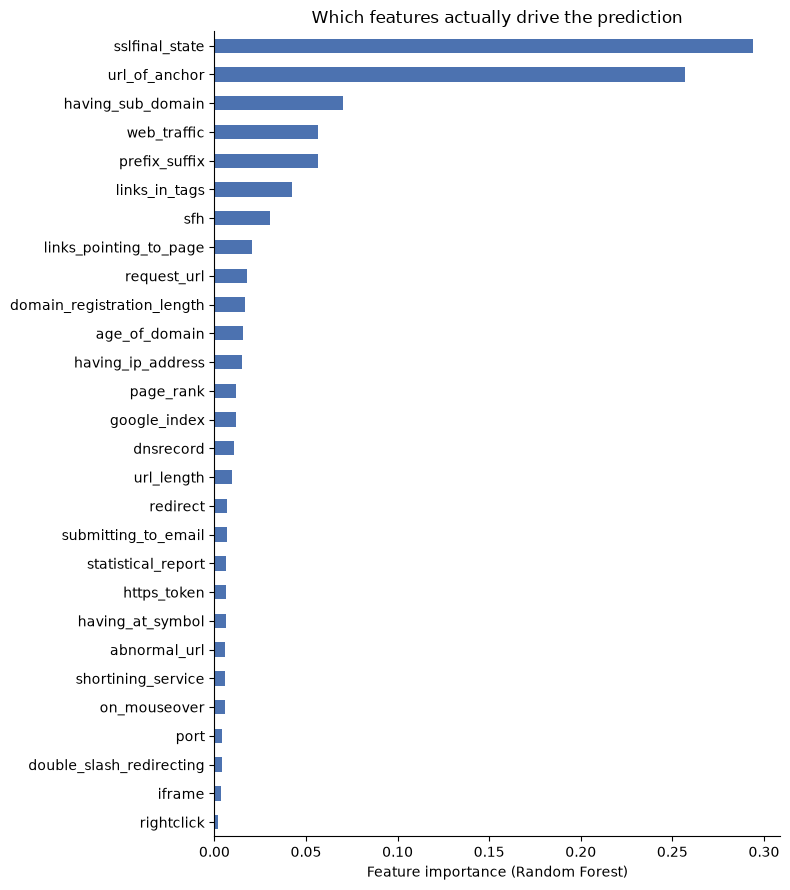

In [27]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
importances.plot.barh(ax=ax, color='#4C72B0')
ax.invert_yaxis()
ax.set_xlabel('Feature importance (Random Forest)')
ax.set_title('Which features actually drive the prediction')
sns.despine()
plt.tight_layout()
plt.show()


## RF tuning

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [4, 6, 8, 10, 12, 16, None],
    'n_estimators': [300, 400, 500, 600],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
grid_search.fit(X_train_d, y_train_d)

print('Best params:', grid_search.best_params_)
print(f'Best CV ROC AUC: {grid_search.best_score_:.4f}')


Best params: {'max_depth': 12, 'n_estimators': 300}
Best CV ROC AUC: 0.9908


In [29]:
rf_tuned = grid_search.best_estimator_

y_pred_rf_tuned = rf_tuned.predict(X_test_d)
y_proba_rf_tuned = rf_tuned.predict_proba(X_test_d)[:, 1]

print(f'Accuracy: {accuracy_score(y_test_d, y_pred_rf_tuned):.4f}')
print(classification_report(y_test_d, y_pred_rf_tuned))
print(f'ROC AUC: {roc_auc_score(y_test_d, y_proba_rf_tuned):.4f}')


Accuracy: 0.9424
              precision    recall  f1-score   support

          -1       0.96      0.93      0.94       603
           1       0.92      0.96      0.94       561

    accuracy                           0.94      1164
   macro avg       0.94      0.94      0.94      1164
weighted avg       0.94      0.94      0.94      1164

ROC AUC: 0.9885


In [30]:
model_comparison.loc['Random Forest (tuned)'] = {
    'recall (-1, phishing)': recall_score(y_test_d, y_pred_rf_tuned, pos_label=-1),
    'recall (1, legitimate)': recall_score(y_test_d, y_pred_rf_tuned, pos_label=1),
    'accuracy': accuracy_score(y_test_d, y_pred_rf_tuned),
    'roc_auc': roc_auc_score(y_test_d, y_proba_rf_tuned),
}
model_comparison.round(4)


,"recall (-1, phishing)","recall (1, legitimate)",accuracy,roc_auc
Logistic Regression,0.9055,0.9287,0.9167,0.9707
Random Forest,0.9370,0.9590,0.9476,0.9881
Gradient Boosting,0.9287,0.9572,0.9424,0.9866
Random Forest (tuned),0.9254,0.9608,0.9424,0.9885


## XGBoost

In [31]:
from xgboost import XGBClassifier

# XGBoost requires labels in {0, 1}, not {-1, 1}
y_train_d_xgb = (y_train_d == 1).astype(int)
y_test_d_xgb = (y_test_d == 1).astype(int)

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_d, y_train_d_xgb)

y_pred_xgb = pd.Series(xgb_model.predict(X_test_d)).map({0: -1, 1: 1}).values
y_proba_xgb = xgb_model.predict_proba(X_test_d)[:, 1]

print(f'Accuracy: {accuracy_score(y_test_d, y_pred_xgb):.4f}')
print(classification_report(y_test_d, y_pred_xgb))
print(f'ROC AUC: {roc_auc_score(y_test_d, y_proba_xgb):.4f}')


Accuracy: 0.9502
              precision    recall  f1-score   support

          -1       0.96      0.95      0.95       603
           1       0.94      0.96      0.95       561

    accuracy                           0.95      1164
   macro avg       0.95      0.95      0.95      1164
weighted avg       0.95      0.95      0.95      1164

ROC AUC: 0.9922


In [32]:
model_comparison.loc['XGBoost'] = {
    'recall (-1, phishing)': recall_score(y_test_d, y_pred_xgb, pos_label=-1),
    'recall (1, legitimate)': recall_score(y_test_d, y_pred_xgb, pos_label=1),
    'accuracy': accuracy_score(y_test_d, y_pred_xgb),
    'roc_auc': roc_auc_score(y_test_d, y_proba_xgb),
}
model_comparison.round(4)


,"recall (-1, phishing)","recall (1, legitimate)",accuracy,roc_auc
Logistic Regression,0.9055,0.9287,0.9167,0.9707
Random Forest,0.9370,0.9590,0.9476,0.9881
Gradient Boosting,0.9287,0.9572,0.9424,0.9866
Random Forest (tuned),0.9254,0.9608,0.9424,0.9885
XGBoost,0.9453,0.9554,0.9502,0.9922


## XGBoost tuning (GridSearchCV)

In [33]:
xgb_param_grid = {
    'max_depth': [3, 4, 6],
    'n_estimators': [300, 400, 500, 600],
    'learning_rate': [0.01, 0.05, 0.1],
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
)
xgb_grid_search.fit(X_train_d, y_train_d_xgb)

print('Best params:', xgb_grid_search.best_params_)
print(f'Best CV ROC AUC: {xgb_grid_search.best_score_:.4f}')


Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 600}
Best CV ROC AUC: 0.9924


In [34]:
xgb_tuned = xgb_grid_search.best_estimator_

y_pred_xgb_tuned = pd.Series(xgb_tuned.predict(X_test_d)).map({0: -1, 1: 1}).values
y_proba_xgb_tuned = xgb_tuned.predict_proba(X_test_d)[:, 1]

print(f'Accuracy: {accuracy_score(y_test_d, y_pred_xgb_tuned):.4f}')
print(classification_report(y_test_d, y_pred_xgb_tuned))
print(f'ROC AUC: {roc_auc_score(y_test_d, y_proba_xgb_tuned):.4f}')


Accuracy: 0.9562
              precision    recall  f1-score   support

          -1       0.96      0.95      0.96       603
           1       0.95      0.96      0.95       561

    accuracy                           0.96      1164
   macro avg       0.96      0.96      0.96      1164
weighted avg       0.96      0.96      0.96      1164

ROC AUC: 0.9922


In [35]:
model_comparison.loc['XGBoost (tuned)'] = {
    'recall (-1, phishing)': recall_score(y_test_d, y_pred_xgb_tuned, pos_label=-1),
    'recall (1, legitimate)': recall_score(y_test_d, y_pred_xgb_tuned, pos_label=1),
    'accuracy': accuracy_score(y_test_d, y_pred_xgb_tuned),
    'roc_auc': roc_auc_score(y_test_d, y_proba_xgb_tuned),
}
model_comparison.round(4)


,"recall (-1, phishing)","recall (1, legitimate)",accuracy,roc_auc
Logistic Regression,0.9055,0.9287,0.9167,0.9707
Random Forest,0.9370,0.9590,0.9476,0.9881
Gradient Boosting,0.9287,0.9572,0.9424,0.9866
Random Forest (tuned),0.9254,0.9608,0.9424,0.9885
XGBoost,0.9453,0.9554,0.9502,0.9922
XGBoost (tuned),0.9536,0.9590,0.9562,0.9922


## ROC comparison across all models

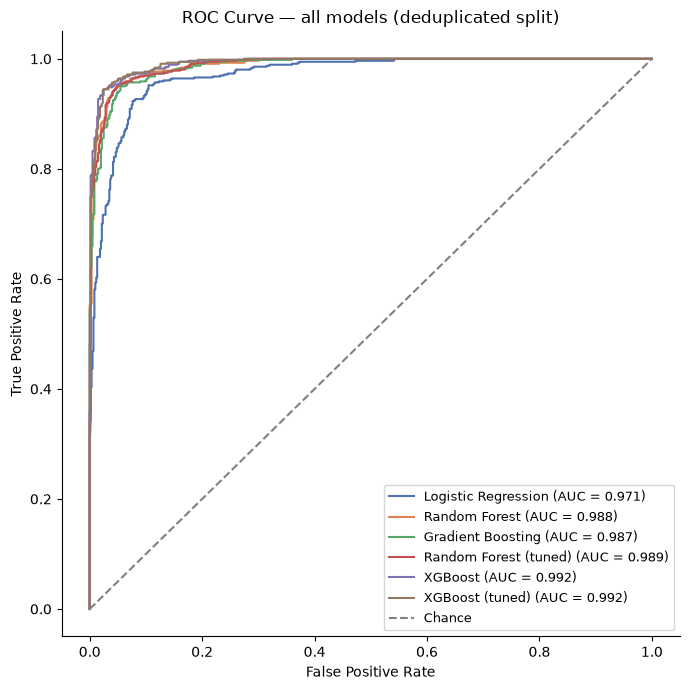

In [36]:
all_models = [
    ('Logistic Regression', y_proba_dedup),
    ('Random Forest', y_proba_rf),
    ('Gradient Boosting', y_proba_gb),
    ('Random Forest (tuned)', y_proba_rf_tuned),
    ('XGBoost', y_proba_xgb),
    ('XGBoost (tuned)', y_proba_xgb_tuned),
]
colors = sns.color_palette('deep', len(all_models))

fig, ax = plt.subplots(figsize=(7, 7))
for (name, proba), color in zip(all_models, colors):
    fpr_i, tpr_i, _ = roc_curve(y_test_d, proba, pos_label=1)
    auc_i = roc_auc_score(y_test_d, proba)
    ax.plot(fpr_i, tpr_i, color=color, label=f'{name} (AUC = {auc_i:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — all models (deduplicated split)')
ax.legend(loc='lower right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()
